# 0050 EnbPI

This notebook replaces the simulated M1M3/M1M9 data with the same 0050.TW adjusted-close data and train/test periods used in `KF_0050dispredlog.ipynb`. Prices are transformed to log prices before causal KF decomposition. For the low component, moving blocks of base-ARIMA one-step residuals are resampled and added back to the original fitted time path to train B ARIMA models; the high component uses B MSE-ANN models with the same block membership to predict the complete H_t level. Nested OOB mean aggregation and separate low/high/final EnbPI calibration then follow. At prediction time every ARIMA parameter set is conditioned on the actual causal KF-low history. Final price forecasts and interval endpoints are transformed back with `exp`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import importlib

from kf_forecasting.models import kf_enbpi
importlib.reload(kf_enbpi)

from kf_forecasting.models.kf_enbpi import EnbPIConfig, run_kf_enbpi

np.random.seed(42)
pd.set_option('display.precision', 4)
print(f'Loaded kf_enbpi from: {kf_enbpi.__file__}')

Loaded kf_enbpi from: C:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_enbpi.py


## 0050 data

The loader below uses `0050.TW`, `auto_adjust=True`, training from 2023-01-01 through 2025-12-31, and testing from 2026-01-01 through 2026-05-31. It retains both adjusted prices and `log(price)`: only log prices enter KF/ARIMA/ANN/EnbPI. Yahoo's `end` is exclusive, so one day is added to include the requested final date.

In [26]:
def load_0050_actual_data(
    ticker='0050.TW',
    train_start='2022-01-01',
    train_end='2024-12-31',
    test_start='2025-01-01',
    test_end='2025-12-31',
):
    download_end = (pd.Timestamp(test_end) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    raw = yf.download(
        ticker, start=train_start, end=download_end,
        auto_adjust=True, progress=False,
    )
    if raw.empty:
        raise ValueError(f'No market data downloaded for {ticker}.')

    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close = close.dropna().astype(float)

    train_close = close.loc[train_start:train_end]
    test_close = close.loc[test_start:test_end]
    if train_close.empty:
        raise ValueError(f'No training data found between {train_start} and {train_end}.')
    if test_close.empty:
        raise ValueError(f'No test data found between {test_start} and {test_end}.')

    full_close = pd.concat([train_close, test_close])
    if (full_close <= 0).any():
        raise ValueError('Log-price modeling requires strictly positive prices.')
    full_log_close = np.log(full_close)
    train_log_close = np.log(train_close)
    test_log_close = np.log(test_close)
    return {
        'ticker': ticker,
        'train_period': f'{train_start} to {train_end}',
        'test_period': f'{test_start} to {test_end}',
        'full_dates': pd.to_datetime(full_close.index),
        'train_dates': pd.to_datetime(train_close.index),
        'test_dates': pd.to_datetime(test_close.index),
        'full_series': full_log_close.to_numpy(dtype=float),
        'train_series': train_log_close.to_numpy(dtype=float),
        'test_series': test_log_close.to_numpy(dtype=float),
        'full_price_series': full_close.to_numpy(dtype=float),
        'train_price_series': train_close.to_numpy(dtype=float),
        'test_price_series': test_close.to_numpy(dtype=float),
    }

## EnbPI configuration

The EnbPI structure uses separate raw OOB residual pools for low, high, and final forecasts. Before each forecast batch, the mean low/high OOB residuals correct the component point forecasts; interval quantiles use mean-centered residuals so bias is not counted twice. `process_variance=0.05` and `measurement_variance=10.0` match `KF_0050dispredlog`. BIC selects the ARIMA order once from the KF low log-price training series. Low-frequency bootstrap blocks contain centered one-step ARIMA residuals, not concatenated log-price levels. Each bootstrap ARIMA parameter set is filtered on the genuinely available chronological KF-low history through t-1. The fixed random seed controls moving-block sampling and ANN initialization.

In [27]:
config = EnbPIConfig(
    window_size=4,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,  # round(sqrt(number of supervised training windows))
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,
    arima_max_p=4,
    arima_max_q=4,
    ann_hidden_layers=(32, 10),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=5e-4,
    ann_target_standardization=True,
    ann_early_stopping=False,  # disable sklearn random validation split
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
    process_variance=0.05,
    measurement_variance=10.0,
)

market_data = load_0050_actual_data()
observed_log = market_data['full_series']
train_size = len(market_data['train_series'])
horizon = len(market_data['test_series'])

print(f"Ticker       : {market_data['ticker']}")
print(f"Train period : {market_data['train_period']} ({train_size} points)")
print(f"Test period  : {market_data['test_period']} ({horizon} points)")
print(f"Seeds        : numpy=42, bootstrap/ANN={config.random_state}")

Ticker       : 0050.TW
Train period : 2022-01-01 to 2024-12-31 (727 points)
Test period  : 2025-01-01 to 2025-12-31 (243 points)
Seeds        : numpy=42, bootstrap/ANN=1234


## Fit and forecast

This is a real-data evaluation: the 2026 test log prices are not used to fit the initial models. With `batch_size=1`, each close is revealed after its forecast and its log value is then allowed to update the causal KF history and all three EnbPI residual pools. Final point forecasts and interval endpoints are exponentiated back to adjusted-price units. ARIMA parameters are not re-estimated during testing; each bootstrap parameter set is filtered on the available chronological history.

In [28]:
result = run_kf_enbpi(
    observed_log,
    train_size,
    config=config,
    model_name='0050.TW',
)

log_final_summary, component_summary = result.summary_tables()
metrics = result.metrics()
component_summary.insert(2, 'scale', 'log')
price_truth = market_data['test_price_series']
price_point = np.exp(result.point)
price_lower = np.exp(result.lower)
price_upper = np.exp(result.upper)
price_error = price_truth - price_point
price_covered = (price_truth >= price_lower) & (price_truth <= price_upper)
forecast_bias = float(np.mean(price_error))
log_forecast_bias = float(np.mean(result.truth - result.point))
low_reference_price = np.exp(result.estimated_low[result.test_times])
low_point_price = np.exp(result.low_point)
low_lower_price = np.exp(result.low_lower)
low_upper_price = np.exp(result.low_upper)
low_price_error = low_reference_price - low_point_price
low_price_covered = (low_reference_price >= low_lower_price) & (low_reference_price <= low_upper_price)
price_summary = pd.DataFrame([{
    'model': '0050.TW',
    'scale': 'adjusted_price',
    'mse': float(np.mean(price_error ** 2)),
    'rmse': float(np.sqrt(np.mean(price_error ** 2))),
    'coverage_percent': float(100.0 * np.mean(price_covered)),
    'mean_width': float(np.mean(price_upper - price_lower)),
    'forecast_bias_truth_minus_prediction': forecast_bias,
    'elapsed_seconds': result.elapsed_seconds,
}])
effective_block_length = config.block_length or max(2, int(round(np.sqrt(train_size - config.window_size))))
summary_rows = []
def add_summary(section, metric, value):
    summary_rows.append({'section': section, 'metric': metric, 'value': value})

add_summary('data', 'ticker', market_data['ticker'])
add_summary('data', 'train_period', market_data['train_period'])
add_summary('data', 'test_period', market_data['test_period'])
add_summary('data', 'train_points', train_size)
add_summary('data', 'test_points', horizon)
add_summary('data', 'modeling_scale', 'log adjusted price')
add_summary('config', 'window_size', config.window_size)
add_summary('config', 'alpha', config.alpha)
add_summary('config', 'n_bootstrap', config.n_bootstrap)
add_summary('config', 'block_length', effective_block_length)
add_summary('config', 'batch_size', config.batch_size)
add_summary('config', 'beta_grid_size', config.beta_grid_size)
add_summary('config', 'oob_bias_correction', config.oob_bias_correction)
add_summary('config', 'oob_bias_correction_mode', config.oob_bias_correction_mode)
add_summary('config', 'selected_arima_order', str(result.selected_arima_order))
add_summary('config', 'arima_bootstrap_mode', 'moving blocks of centered base-ARIMA one-step residuals')
add_summary('config', 'arima_testing_history', 'actual causal KF-low through t-1')
add_summary('config', 'ann_target', 'complete KF-high level H_t')
add_summary('config', 'ann_target_standardization', config.ann_target_standardization)
add_summary('config', 'ann_validation', 'chronological rolling-origin; no random validation split')
add_summary('config', 'ann_rolling_splits', config.ann_rolling_splits)
add_summary('config', 'ann_iteration_candidates', str(config.ann_iteration_candidates))
add_summary('fit', 'ann_selected_max_iters', str(result.selected_ann_max_iters.tolist()))
add_summary('fit', 'ann_mean_rolling_validation_mse', float(np.mean(result.ann_rolling_validation_mse)))
add_summary('config', 'ann_hidden_layers', str(config.ann_hidden_layers))
add_summary('config', 'ann_max_iter', config.ann_max_iter)
add_summary('config', 'ann_learning_rate_init', config.ann_learning_rate_init)
add_summary('config', 'random_state', config.random_state)
add_summary('config', 'kf_process_variance', config.process_variance)
add_summary('config', 'kf_measurement_variance', config.measurement_variance)
add_summary('final_price', 'mse', float(np.mean(price_error ** 2)))
add_summary('final_price', 'rmse', float(np.sqrt(np.mean(price_error ** 2))))
add_summary('final_price', 'forecast_bias_truth_minus_prediction', forecast_bias)
add_summary('final_price', 'coverage_percent', float(100.0 * np.mean(price_covered)))
add_summary('final_price', 'mean_interval_width', float(np.mean(price_upper - price_lower)))
add_summary('final_price', 'median_interval_width', float(np.median(price_upper - price_lower)))
add_summary('final_log', 'mse', metrics['mse'])
add_summary('final_log', 'rmse', metrics['rmse'])
add_summary('final_log', 'forecast_bias_truth_minus_prediction', log_forecast_bias)
add_summary('final_log', 'coverage_percent', metrics['coverage_percent'])
add_summary('final_log', 'mean_interval_width', metrics['mean_width'])
add_summary('final_log', 'mean_beta', metrics['mean_beta'])
add_summary('final_log', 'mean_oob_bias_correction', metrics['mean_bias_correction'])
add_summary('low_price_vs_kf', 'mse', float(np.mean(low_price_error ** 2)))
add_summary('low_price_vs_kf', 'rmse', float(np.sqrt(np.mean(low_price_error ** 2))))
add_summary('low_price_vs_kf', 'coverage_percent', float(100.0 * np.mean(low_price_covered)))
add_summary('low_price_vs_kf', 'mean_interval_width', float(np.mean(low_upper_price - low_lower_price)))
add_summary('low_log_vs_kf', 'mse', metrics['low_kf_mse'])
add_summary('low_log_vs_kf', 'rmse', metrics['low_kf_rmse'])
add_summary('low_log_vs_kf', 'coverage_percent', 100.0 * metrics['low_enbpi_coverage'])
add_summary('low_log_vs_kf', 'mean_interval_width', metrics['low_enbpi_mean_width'])
add_summary('low_log_vs_kf', 'mean_beta', metrics['low_mean_beta'])
add_summary('low_log_vs_kf', 'mean_oob_bias_correction', metrics['low_mean_bias_correction'])
add_summary('high_log_vs_kf', 'mse', metrics['high_kf_mse'])
add_summary('high_log_vs_kf', 'rmse', metrics['high_kf_rmse'])
add_summary('high_log_vs_kf', 'coverage_percent', 100.0 * metrics['high_enbpi_coverage'])
add_summary('high_log_vs_kf', 'mean_interval_width', metrics['high_enbpi_mean_width'])
add_summary('high_log_vs_kf', 'mean_beta', metrics['high_mean_beta'])
add_summary('high_log_vs_kf', 'mean_oob_bias_correction', metrics['high_mean_bias_correction'])
add_summary('ensemble', 'mean_oob_models_per_training_point', metrics['mean_oob_models_per_train_point'])
add_summary('ensemble', 'min_oob_models_per_training_point', metrics['min_oob_models_per_train_point'])
add_summary('ensemble', 'ann_nonconverged_models', int(metrics['ann_nonconverged_models']))
add_summary('runtime', 'elapsed_seconds', metrics['elapsed_seconds'])
complete_summary = pd.DataFrame(summary_rows)

display(complete_summary)
display(price_summary)
display(log_final_summary.assign(scale='log_price'))
display(component_summary)
log_frame = result.frame()
price_frame = pd.DataFrame({
    'date': market_data['test_dates'],
    'truth_price': price_truth,
    'point_price': price_point,
    'lower_price': price_lower,
    'upper_price': price_upper,
    'covered': price_covered,
})
display(price_frame.head())

c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,section,metric,value
0,data,ticker,0050.TW
1,data,train_period,2022-01-01 to 2024-12-31
2,data,test_period,2025-01-01 to 2025-12-31
3,data,train_points,727
4,data,test_points,243
...,...,...,...
58,high_log_vs_kf,mean_oob_bias_correction,0.0
59,ensemble,mean_oob_models_per_training_point,10.4371
60,ensemble,min_oob_models_per_training_point,6.0
61,ensemble,ann_nonconverged_models,0


,model,scale,mse,rmse,coverage_percent,mean_width,forecast_bias_truth_minus_prediction,elapsed_seconds
0,0050.TW,adjusted_price,0.6571,0.8106,94.2387,2.8044,0.0097,53.9248


,model,data_seed,ensemble_seed,arima_order,mse,rmse,coverage_percent,mean_width,mean_beta,mean_bias_correction,bias_correction_mode,ann_selected_max_iter_mean,ann_rolling_validation_mse,ann_nonconverged_models,elapsed_seconds,scale
0,0050.TW,None,1234,"(2, 0, 0)",0.0003,0.0179,94.2387,0.0554,0.0252,0.0011,combined,129.1667,0.0005,0,53.9248,log_price


,component,reference,scale,mse,rmse,coverage_percent,enbpi_mean_width,mean_beta,mean_bias_correction
0,low_arima,kalman_low,log,2.4747e-06,0.0016,93.0041,0.0054,0.0353,0.0
1,high_ann_mse,kalman_high,log,2.7591e-04,0.0166,94.6502,0.0517,0.0310,0.0


,date,truth_price,point_price,lower_price,upper_price,covered
0,2025-01-02,46.5716,47.1784,45.8618,48.3986,True
1,2025-01-03,47.0396,46.7568,45.4521,47.9662,True
2,2025-01-06,48.5156,46.9085,45.5994,48.1217,False
3,2025-01-07,49.0556,47.9798,46.6331,49.2211,True
4,2025-01-08,48.3236,48.7640,47.3945,50.0248,True


## Date-aligned forecast diagnostics

Low and high intervals are separate component EnbPI intervals calibrated in log space against causal KF component references. The low log-level interval is exponentiated to a price-level trend interval; the high component remains a log residual. The final log-price interval is exponentiated endpoint by endpoint and is not obtained by adding the component intervals.

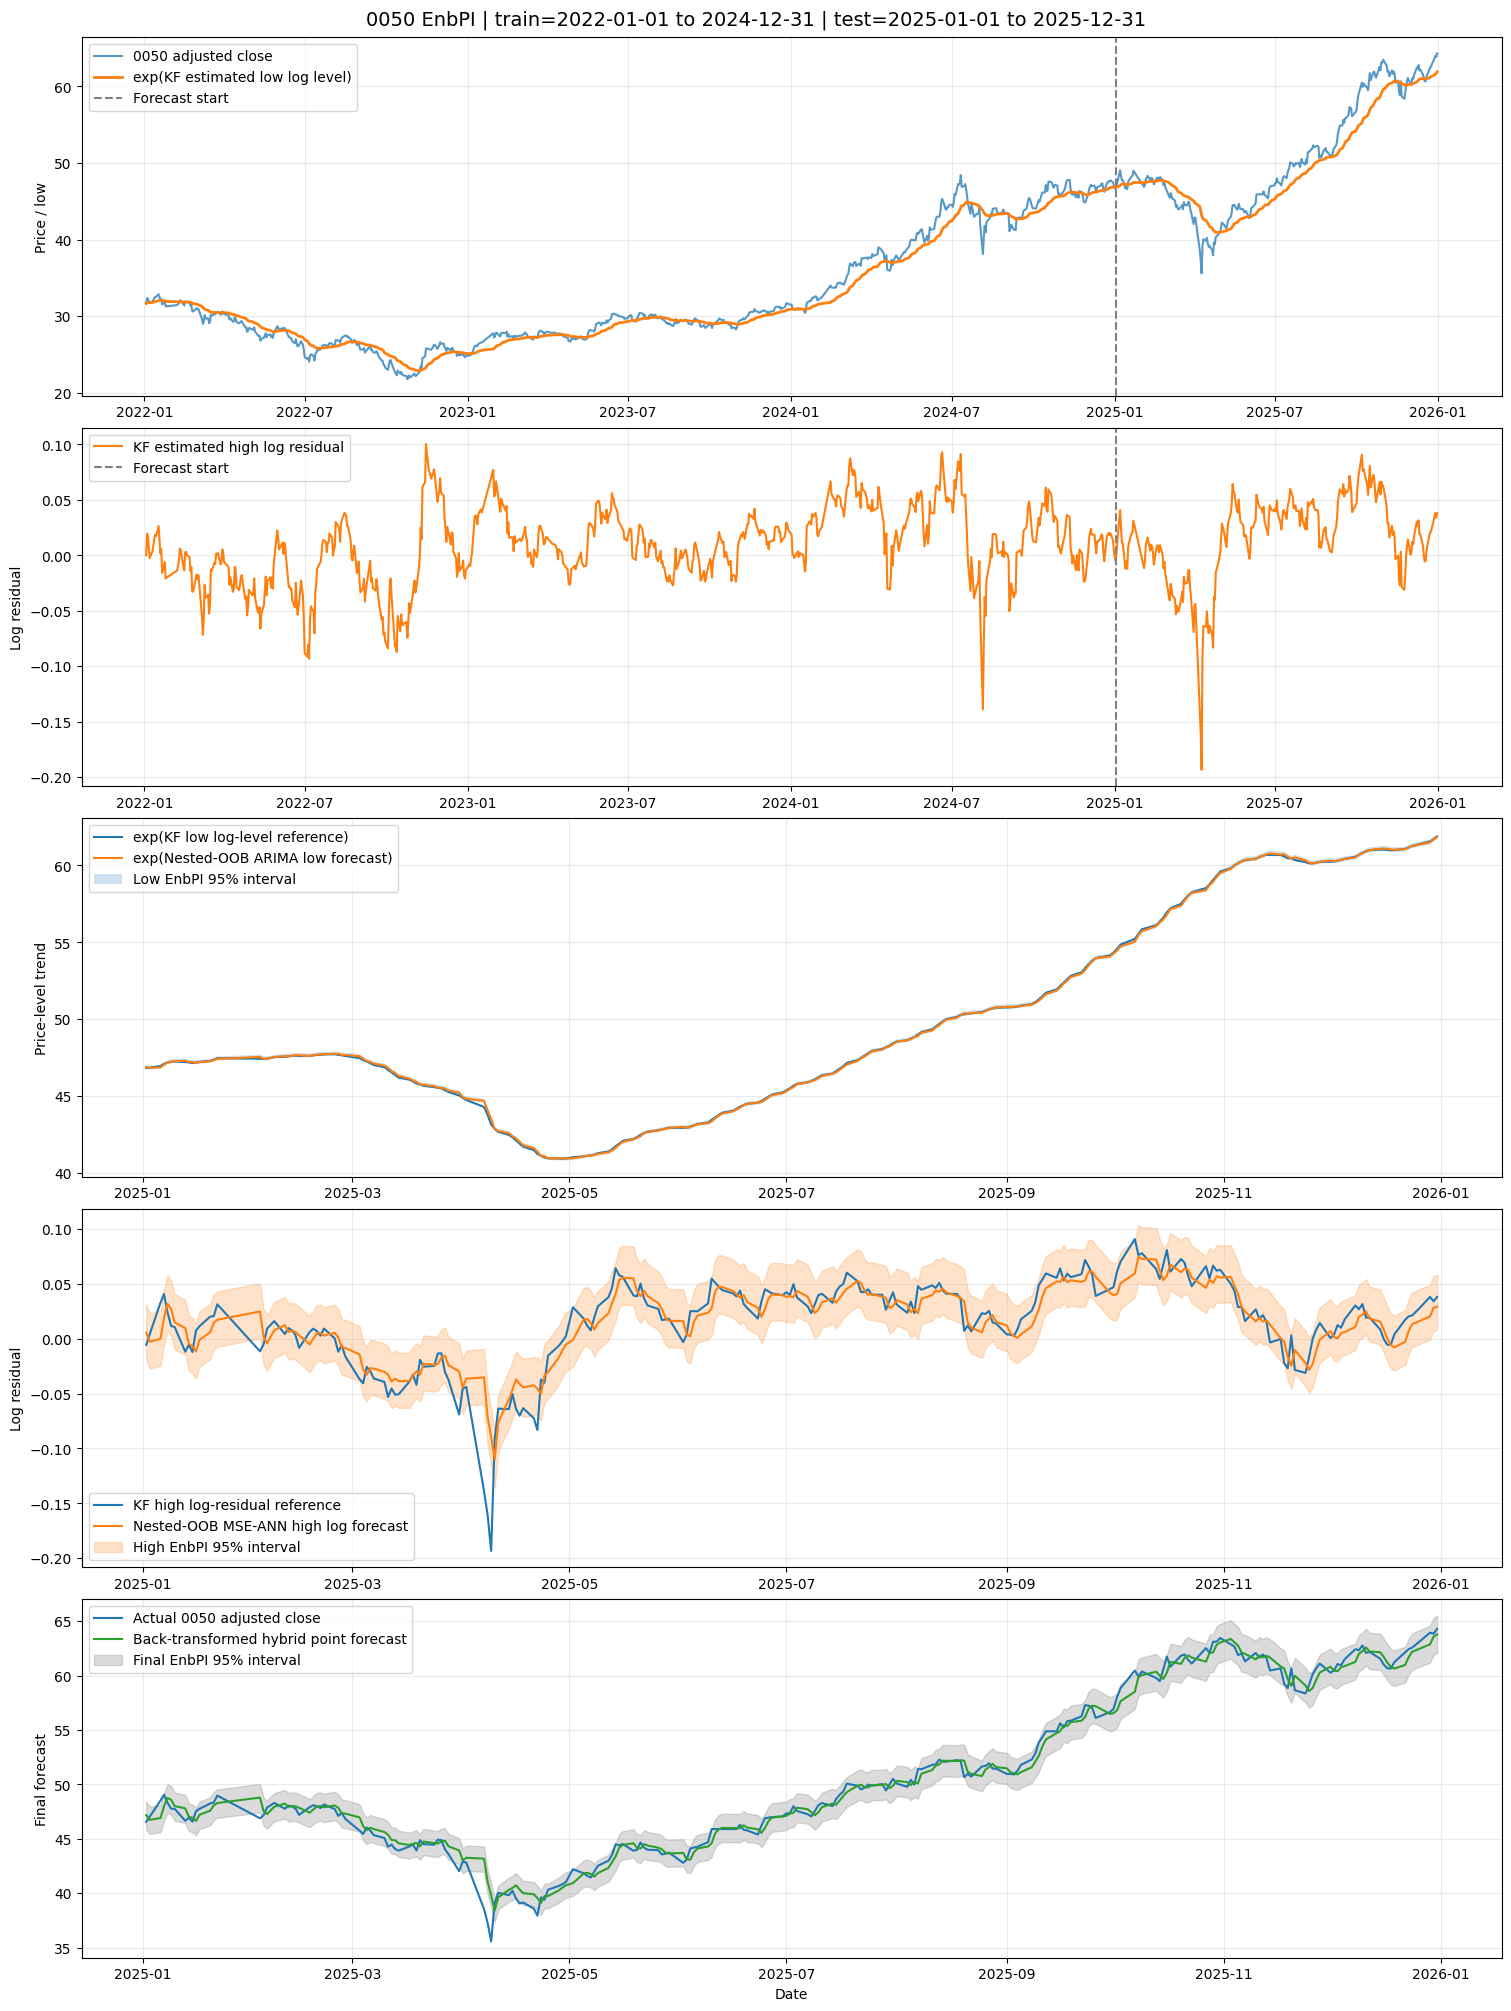

In [29]:
full_dates = market_data['full_dates']
test_dates = market_data['test_dates']
forecast_start = test_dates[0]
frame = log_frame

fig, axes = plt.subplots(5, 1, figsize=(15, 20), constrained_layout=True)
fig.suptitle(
    f"0050 EnbPI | train={market_data['train_period']} | test={market_data['test_period']}",
    fontsize=14,
)

axes[0].plot(full_dates, market_data['full_price_series'], label='0050 adjusted close', alpha=0.75)
axes[0].plot(full_dates, np.exp(result.estimated_low), label='exp(KF estimated low log level)', linewidth=2)
axes[0].axvline(forecast_start, color='gray', linestyle='--', label='Forecast start')
axes[0].set_ylabel('Price / low')
axes[0].legend(loc='best')

axes[1].plot(full_dates, result.estimated_high, color='tab:orange', label='KF estimated high log residual')
axes[1].axvline(forecast_start, color='gray', linestyle='--', label='Forecast start')
axes[1].set_ylabel('Log residual')
axes[1].legend(loc='best')

axes[2].plot(test_dates, np.exp(frame['low_reference']), label='exp(KF low log-level reference)')
axes[2].plot(test_dates, np.exp(frame['low_point']), label='exp(Nested-OOB ARIMA low forecast)')
axes[2].fill_between(
    test_dates, np.exp(frame['low_lower']), np.exp(frame['low_upper']), alpha=0.22,
    label='Low EnbPI 95% interval',
)
axes[2].set_ylabel('Price-level trend')
axes[2].legend(loc='best')

axes[3].plot(test_dates, frame['high_reference'], label='KF high log-residual reference')
axes[3].plot(test_dates, frame['high_point'], label='Nested-OOB MSE-ANN high log forecast')
axes[3].fill_between(
    test_dates, frame['high_lower'], frame['high_upper'], color='tab:orange', alpha=0.22,
    label='High EnbPI 95% interval',
)
axes[3].set_ylabel('Log residual')
axes[3].legend(loc='best')

axes[4].plot(test_dates, price_truth, label='Actual 0050 adjusted close')
axes[4].plot(test_dates, price_point, color='tab:green', label='Back-transformed hybrid point forecast')
axes[4].fill_between(
    test_dates, price_lower, price_upper, color='gray', alpha=0.28,
    label='Final EnbPI 95% interval',
)
axes[4].set_ylabel('Final forecast')
axes[4].set_xlabel('Date')
axes[4].legend(loc='best')

for axis in axes:
    axis.grid(alpha=0.25)
plt.show()